# Implementasi Lexical Normalization pada Teks Twitter Berbahasa Indonesia untuk Deteksi Ujaran Kebencian

Pipeline:
1. Pre-processing (Sentence Segmentation → Tokenisasi + Cleaning + Lowercase)
2. Lexical Normalization (Normalisasi Kata Tidak Baku → Abbreviation Expansion)
3. Stopword Removal
4. Stemming
5. Text Representation (TF-IDF)
6. Pemodelan (Naive Bayes)

## 1. Instalasi dan Import Library

In [ ]:
%pip install nltk Sastrawi scikit-learn matplotlib seaborn

In [25]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os


nltk.download('punkt')
nltk.download('punkt_tab')

from typing import List, Dict
from nltk.tokenize import sent_tokenize, word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# TF-IDF dan Naive Bayes
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Load Dataset

In [26]:
# Sesuaikan path dataset kalian
df = pd.read_csv('data/data.csv', encoding='latin-1')

print('Shape dataset:', df.shape)
print('\nKolom:', df.columns.tolist())
print('\nDistribusi label Hate Speech:')
print(df['HS'].value_counts())
print(r'\Sample Data')
df.head()

Shape dataset: (13169, 13)

Kolom: ['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']

Distribusi label Hate Speech:
HS
0    7608
1    5561
Name: count, dtype: int64
\Sample Data


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1,0,1,1,0,0,0,0,0,1,0


## 3. Kelas Preprocessor

Semua tahap pipeline dikemas dalam satu kelas `IndonesianNLPPreprocessor`.

In [27]:
class IndonesianNLPPreprocessor:

    def __init__(self):
        # Inisialisasi stemmer Sastrawi (algoritma Nazief & Adriani)
        factory = StemmerFactory()
        self.stemmer = factory.create_stemmer()

        # Inisialisasi stopword Bahasa Indonesia dari Sastrawi
        stop_factory = StopWordRemoverFactory()
        self.stopwords = set(stop_factory.get_stop_words())

        # Menghapus kata negasi dari stopword
        negasi = {'tidak', 'bukan', 'jangan', 'belum', 'tanpa', 'tiada', 'tak'}
        self.stopwords = self.stopwords - negasi

        # Kamus Normalisasi Kata Tidak Baku (Slang)
        self.slang_dict = {
            # Kata ganti orang
            'gue'   : 'saya',
            'gw'    : 'saya',
            'w'     : 'saya',
            'aku'   : 'saya',
            'ak'    : 'saya',
            'lu'    : 'kamu',
            'loe'   : 'kamu',
            'lo'    : 'kamu',
            'elo'   : 'kamu',
            'u'     : 'kamu',
            'elu'   : 'kamu',
            'dia'   : 'dia',
            'dy'    : 'dia',
            'doi'   : 'dia',
            'gua': 'saya',
            'sy': 'saya',
            'km': 'kamu',
            'kau': 'kamu',
            'mu': 'kamu',
            'mrk': 'mereka',

            # Kata Ganti & Sapaan
            'kalian' : 'kalian',
            'ni'     : 'ini',
            'tu'     : 'itu',
            'si'     : 'si',
            'bang'   : 'abang',
            'mas'    : 'mas',
            'pak'    : 'bapak',

            # Kata depan & Konjungsi
            'pas': 'saat',
            'dlm': 'dalam',
            'spt': 'seperti',
            'kyk': 'seperti',
            'kayak': 'seperti',
            'kek': 'seperti',
            'sbg': 'sebagai',
            'pdhl': 'padahal',
            'drpd': 'daripada',
            'ama': 'sama',
            'klo': 'kalau',

            # Kata Kerja & Keterangan
            'pake'   : 'pakai',
            'sampe'  : 'sampai',
            'gini'   : 'begini',
            'gitu'   : 'begitu',
            'malah'  : 'malah',
            'pasti'  : 'pasti',
            'banyak' : 'banyak',
            'dulu'   : 'dahulu',
            'nanti'  : 'nanti',
            'coba'   : 'coba',
            'temen'  : 'teman',

            # Negasi
            'gak'   : 'tidak',
            'ga'    : 'tidak',
            'nggak' : 'tidak',
            'ngga'  : 'tidak',
            'enggak': 'tidak',
            'kagak' : 'tidak',
            'gk'    : 'tidak',
            'tdk'   : 'tidak',
            'tak'   : 'tidak',
            'g'     : 'tidak',

            # Intensifier
            'banget': 'sangat',
            'bgt'   : 'sangat',
            'bngt'  : 'sangat',
            'bener' : 'benar',
            'bner'  : 'benar',
            'emg'   : 'memang',
            'emang' : 'memang',
            'mmg'   : 'memang',

            # Kata kerja / umum
            'bilang' : 'berkata',
            'ngomong': 'berbicara',
            'ngobrol': 'berbicara',
            'ngasih' : 'memberi',
            'kasih'  : 'beri',
            'liat'   : 'lihat',
            'diliat' : 'dilihat',
            'liatnya': 'lihatnya',
            'tau'    : 'tahu',
            'taw'    : 'tahu',
            'tw'     : 'tahu',
            'mau'    : 'mau',
            'mo'     : 'mau',
            'udah'   : 'sudah',
            'udh'    : 'sudah',
            'dah'    : 'sudah',
            'sdh'    : 'sudah',
            'belom'  : 'belum',
            'blm'    : 'belum',
            'blum'   : 'belum',
            'bisa'   : 'bisa',
            'bs'     : 'bisa',
            'kaga'   : 'tidak',
            'aja'    : 'saja',
            'doang'  : 'saja',
            'dong'   : 'dong',
            'sih'    : 'sih',
            'deh'    : 'deh',
            'nih'    : 'ini',
            'tuh'    : 'itu',
            'tp'     : 'tapi',
            'tpi'    : 'tapi',
            'klo'    : 'kalau',
            'klo'    : 'kalau',
            'kl'     : 'kalau',
            'klu'    : 'kalau',
            'kalo'   : 'kalau',
            'klau'   : 'kalau',
            'krn'    : 'karena',
            'karna'  : 'karena',
            'krena'  : 'karena',
            'utk'    : 'untuk',
            'buat'   : 'untuk',
            'bwat'   : 'untuk',
            'dgn'    : 'dengan',
            'dg'     : 'dengan',
            'sm'     : 'sama',
            'sama'   : 'sama',
            'jg'     : 'juga',
            'juga'   : 'juga',
            'lg'     : 'lagi',
            'lagi'   : 'lagi',
            'jd'     : 'jadi',
            'jadi'   : 'jadi',
            'sdg'    : 'sedang',
            'lagi'   : 'sedang',
            'yg'     : 'yang',
            'bikin': 'membuat',
            'dapet': 'dapat',
            'dpt': 'dapat',
            'br': 'baru',
            'td': 'tadi',
            'trus': 'terus',
            'gt': 'begitu',
            'gitu': 'begitu',
            'gtu': 'begitu',
            'cm': 'cuma',
            'cuman': 'cuma',
            'mngkn': 'mungkin',
            'mgkn': 'mungkin',
            'jgn': 'jangan',
            'bkn': 'bukan',

            # Kata sifat / ekspresi
            'bagus'  : 'bagus',
            'keren'  : 'keren',
            'jelek'  : 'jelek',
            'jahat'  : 'jahat',
            'bego'   : 'bodoh',
            'bodo'   : 'bodoh',
            'goblok' : 'bodoh',
            'tolol'  : 'bodoh',
            'dungu'  : 'bodoh',
            'idiot'  : 'bodoh',
            'gila'   : 'gila',
            'edan'   : 'gila',
            'gilak'  : 'gila',
            'sarap'  : 'gila',
            'kesel'  : 'kesal',
            'sebal'  : 'kesal',
            'sebel'  : 'kesal',
            'marah'  : 'marah',
            'mara'   : 'marah',

            # Partikel & Penegas 
            'lah'    : 'lah',
            'kan'    : 'kan',
            'mah'    : 'mah',
            'pun'    : 'pun',
            'eh'     : 'eh',
            'ah'     : 'ah',
            'kok'    : 'kok',

            # Ekspresi tawa
            'wkwk'   : 'tertawa',
            'wkwkwk' : 'tertawa',
            'wkkwk'  : 'tertawa',
            'haha'   : 'tertawa',
            'hehe'   : 'tertawa',
            'hihi'   : 'tertawa',
            'xixi'   : 'tertawa',
            'kwkwk'  : 'tertawa',

            # Kata kotor yang dinormalisasi
            'bangsat' : 'buruk',
            'brengsek': 'buruk',
            'bajingan': 'buruk',
            'anjing'  : 'buruk',
            'anjir'   : 'buruk',
            'anying'  : 'buruk',
            'babi'    : 'buruk',
            'keparat' : 'buruk',
            'kurang ajar': 'buruk',
            'sialan'  : 'buruk',
            'jancok'  : 'buruk',
            'jancuk'  : 'buruk',
            'jancik'  : 'buruk',
            'jncok'   : 'buruk',
            'kontol'  : 'buruk',
            'kntl'    : 'buruk',
            'memek'   : 'buruk',
            'mek'     : 'buruk',
            'nget'    : 'buruk',
            'taik'    : 'buruk',
            'tai'     : 'buruk',
            'kampret' : 'buruk',
            'kamprit' : 'buruk',
            'asu'     : 'buruk',
            'asuw'    : 'buruk',
            'asuu'    : 'buruk',
            'cuk'     : 'buruk',
            'cok'     : 'buruk',
            'lonte'   : 'buruk',
            'pelacur' : 'buruk',
            'sundal'  : 'buruk',
            'bedebah' : 'buruk',
            'biadab'  : 'buruk',
            'laknat'  : 'buruk',
            'brengsek': 'buruk',
            'iblis'   : 'iblis',
            'setan'   : 'setan',
            'celeng'  : 'buruk',
            'monyet'  : 'buruk',   
            'kera'    : 'buruk',   

            # Kata Kasar / Label Spesifik Dataset 
            'cebong' : 'sebutan politik',
            'kampret': 'sebutan politik',
            'onta'   : 'sebutan rasis',
            'aseng'  : 'sebutan rasis',
            'cina'   : 'china',
            'kapir'  : 'kafir',
            'bacot'  : 'bicara',
            'kontol' : 'kasar',
            'ngentot': 'kasar',
            'memek'  : 'kasar',
            'kunyuk' : 'kasar',
            'setan'  : 'buruk',
            'munafik': 'buruk',

            # Lainnya
            'makasih' : 'terima kasih',
            'mksh'    : 'terima kasih',
            'tks'     : 'terima kasih',
            'sok'     : 'sombong',
            'sotoy'   : 'sok tahu',
            'lebay'   : 'berlebihan',
            'alay'    : 'berlebihan',
            'mending' : 'lebih baik',
            'mendingan': 'lebih baik',
            'gimana'  : 'bagaimana',
            'gmn'     : 'bagaimana',
            'kenapa'  : 'mengapa',
            'knp'     : 'mengapa',
            'siapa'   : 'siapa',
            'sapa'    : 'siapa',
            'napa'    : 'mengapa',
            'kapan'   : 'kapan',
            'kpn'     : 'kapan',
            'dimana'  : 'di mana',
            'dmn'     : 'di mana',
            
            # Ekspresi emosi
            'sedih'   : 'sedih',
            'seneng'  : 'senang',
            'senengg' : 'senang',
            'happy'   : 'senang',
            'baper'   : 'bawa perasaan',
            'baperan' : 'bawa perasaan',
            'bete'    : 'buruk suasana hati',
            'males'   : 'malas',
            'mager'   : 'malas gerak',
            'capek'   : 'lelah',
            'cape'    : 'lelah',
            'caper'   : 'cari perhatian',
            'kzl'     : 'kesal',
            'emosi'   : 'marah',
            'ngamuk'  : 'marah',
            'sewot'   : 'marah',
            'ngambek' : 'merajuk',
            'mewek'   : 'menangis',
            'nangis'  : 'menangis',
            'nangsi'  : 'menangis',
            'seneng'  : 'senang',
            'asik'    : 'menyenangkan',
            'asyik'   : 'menyenangkan',
            'mantap'  : 'bagus',
            'mantep'  : 'bagus',
            'mantul'  : 'mantap betul',
            'josss'   : 'bagus',
            'jos'     : 'bagus',
            'goks'    : 'luar biasa',
            'gokil'   : 'luar biasa',
            'parah'   : 'sangat',   
            'gilaa'   : 'gila',
            'gileeee' : 'gila',
            'anjayy'  : 'buruk',
            'wanjir'  : 'buruk',
            'wkwkwkwk': 'tertawa',
            'lmao'    : 'tertawa',
            'lol'     : 'tertawa',
            '😂'      : 'tertawa', 

            # bahasa gaul modern
            'kepo'    : 'ingin tahu',
            'kepoan'  : 'ingin tahu',
            'bodo amat': 'tidak peduli',
            'ga peduli': 'tidak peduli',
            'gabut'   : 'tidak ada kerjaan',
            'gabuttt' : 'tidak ada kerjaan',
            'gercep'  : 'gerak cepat',
            'modus'   : 'berpura-pura',
            'nyebelin': 'menjengkelkan',
            'nyebel'  : 'menjengkelkan',
            'ribet'   : 'rumit',
            'rempong' : 'rumit',
            'receh'   : 'tidak penting',
            'julid'   : 'iri dengki',
            'julidan' : 'iri dengki',
            'halu'    : 'berhalusinasi',
            'healing' : 'menenangkan diri',
            'baper'   : 'bawa perasaan',
            'bestie'  : 'teman',
            'mantul'  : 'mantap betul',
            'jamet'   : 'urakan',
            'cringe'  : 'memalukan',
            'jijik'   : 'jijik',
            'nyinyir' : 'mengkritik pedas',
            'nyindir' : 'menyindir',
            'ghosting': 'mengabaikan',
            'nge-gas' : 'marah',
            'ngegas'  : 'marah',
            'smg'  : 'semoga',
        }

        # Kamus Abbreviation Expansion (Singkatan)
        self.abbrev_dict = {
            # Twitter-specific
            'rt'   : 'retweet',
            'dm'   : 'pesan langsung',
            'ff'   : 'follow',
            'ootd' : 'outfit of the day',

            # Singkatan umum bahasa Indonesia
            'yg'   : 'yang',
            'dg'   : 'dengan',
            'dgn'  : 'dengan',
            'krn'  : 'karena',
            'krna' : 'karena',
            'utk'  : 'untuk',
            'tdk'  : 'tidak',
            'tdk'  : 'tidak',
            'sdh'  : 'sudah',
            'blm'  : 'belum',
            'jg'   : 'juga',
            'tp'   : 'tapi',
            'tpi'  : 'tapi',
            'ttg'  : 'tentang',
            'ttng' : 'tentang',
            'dr'   : 'dari',
            'dri'  : 'dari',
            'pd'   : 'pada',
            'spy'  : 'supaya',
            'spya' : 'supaya',
            'biar' : 'supaya',
            'sm'   : 'sama',
            'jd'   : 'jadi',
            'lg'   : 'lagi',
            'lbh'  : 'lebih',
            'lbih' : 'lebih',
            'skrg' : 'sekarang',
            'skrang': 'sekarang',
            'skg'  : 'sekarang',
            'kmrn' : 'kemarin',
            'kmrin': 'kemarin',
            'bsk'  : 'besok',
            'bsok' : 'besok',
            'hrs'  : 'harus',
            'hrs'  : 'harus',
            'msh'  : 'masih',
            'msih' : 'masih',
            'sllu' : 'selalu',
            'sll'  : 'selalu',
            'org'  : 'orang',
            'orng' : 'orang',
            'org'  : 'orang',
            'pke'  : 'pakai',
            'pkai' : 'pakai',
            'dpke' : 'dipakai',
            'mslh' : 'masalah',
            'mskpn': 'meskipun',
            'kpd'  : 'kepada',
            'thd'  : 'terhadap',
            'tsb'  : 'tersebut',
            'dll'  : 'dan lain lain',
            'dsb'  : 'dan sebagainya',
            'dkk'  : 'dan kawan kawan',
            'tlg'  : 'tolong',
            'tlng' : 'tolong',
            'plz'  : 'tolong',
            'pls'  : 'tolong',
            'mksh' : 'terima kasih',
            'tks'  : 'terima kasih',
            'tnks' : 'terima kasih',
            'bnr'  : 'benar',
            'bner' : 'benar',
            'salah': 'salah',
            'slh'  : 'salah',
            'smg'  : 'semoga',
            'amp'    : 'dan', 
            'hoax'   : 'berita bohong',
            'ad'     : 'ada',
            'stlh'   : 'setelah',
            'skrg'   : 'sekarang',
            'jkw': 'jokowi',
            'sby': 'susilo bambang yudhoyono',
            'dpr': 'dewan perwakilan rakyat',
            'kpk': 'komisi pemberantasan korupsi',
            'pki': 'partai komunis indonesia',
            'nkri': 'negara kesatuan republik indonesia',
            'pks': 'partai keadilan sejahtera',
            'bpk': 'bapak',
            'bu': 'ibu',
            'mngkn': 'mungkin',
            'mgkn': 'mungkin',
            'pdhl': 'padahal',
            'td': 'tadi',
            'jgn': 'jangan',
            'sd': 'sampai',
            'tgl': 'tanggal',
            'dlm': 'dalam',
            'jkw'    : 'jokowi',
            'anies'  : 'anies baswedan',
            'sandi'  : 'sandiaga uno',
            'prabowo': 'prabowo subianto',
            'ahok'   : 'basuki tjahaja purnama',
            'ri'     : 'republik indonesia',
            'pks'    : 'partai keadilan sejahtera',
            'dki'    : 'daerah khusus ibukota',
            'sb'   : 'seseorang',
            'stlh' : 'setelah',
            'sblm' : 'sebelum',
            'stgh' : 'setengah',
            'dpt'  : 'dapat',
            'dgr'  : 'dengar',
            'dngr' : 'dengar',
            'ntn'  : 'nonton',
            'tggl' : 'tinggal',
            'mnt'  : 'menit',
            'dtg'  : 'datang',
            'prnh' : 'pernah',
            'sdkt' : 'sedikit',
            'bnyk' : 'banyak',
            'byk'  : 'banyak',
            'sgt'  : 'sangat',
            'smp'  : 'sampai',
            'sprt' : 'seperti',
            'skg'  : 'sekarang',
            'gtw'  : 'tidak tahu',
            'idk'  : 'tidak tahu',
            'imo'  : 'menurut saya',
            'imho' : 'menurut saya',
            'fyi'  : 'untuk informasi',
            'btw'  : 'ngomong-ngomong',
            'afaik': 'sejauh yang saya tahu',
            'tbh'  : 'jujur saja',
            'ngl'  : 'tidak bohong',
            'irl'  : 'di dunia nyata',
            'smh'  : 'menggelengkan kepala',
            'istg' : 'demi tuhan',
            'omg'  : 'ya tuhan',
            'wtf'  : 'apa-apaan',
            'wth'  : 'apa-apaan',
            'asap' : 'sesegera mungkin',
            'thx'  : 'terima kasih',
            'ty'   : 'terima kasih',
            'np'   : 'tidak masalah',
            'nvm'  : 'tidak jadi',
            'jk'   : 'bercanda',
            'lmk'  : 'beritahu saya',
            'hmu'  : 'hubungi saya',
            'ootw' : 'outfit of the week',
            'sotd' : 'song of the day',
        }

    # 1. Sentence Segmentation: Memecah teks menjadi kalimat-kalimat terpisah
    def sentence_segmentation(self, text: str) -> List[str]:
        if pd.isna(text):
            return []
        return sent_tokenize(str(text))

    # 2. Tokenisasi + Cleaning + Lowercase: Memecah kalimat jadi token, membersihkan noise, dan menyeragamkan huruf
    def tokenize(self, text: str) -> List[str]:
        if pd.isna(text):
            return []
        text = str(text).lower()                             # lowercase
        text = re.sub(r'http\S+', '', text)                  # hapus URL
        text = re.sub(r'@\w+', 'user', text)                 # ganti mention jadi 'user'
        text = re.sub(r'#\w+', '', text)                     # hapus hashtag
        text = re.sub(r'\d+', '', text)                      # hapus angka
        text = re.sub(r'[^\w\s]', ' ', text)                 # hapus tanda baca
        text = re.sub(r'\s+', ' ', text).strip()             # normalkan spasi
        tokens = word_tokenize(text)
        return [t for t in tokens if len(t) > 1]             # buang token 1 karakter

    # 3. Normalisasi Kata Tidak Baku: Mengganti kata slang ke bentuk baku menggunakan kamus 
    def normalize_slang(self, tokens: List[str]) -> List[str]:
        return [self.slang_dict.get(t, t) for t in tokens]

    
    # 4. Abbreviation Expansion: Memperluas singkatan ke bentuk lengkap menggunakan kamus 
    def expand_abbrev(self, tokens: List[str]) -> List[str]:
        result = []
        for t in tokens:
            if t in self.abbrev_dict:
                result.extend(self.abbrev_dict[t].split())
            else:
                result.append(t)
        return result

    
    # 5. Stopword Removal
    def remove_stopwords(self, tokens: List[str]) -> List[str]:
        return [t for t in tokens if t not in self.stopwords]

    
    # 6. Stemming: Mengubah kata berimbuhan ke kata dasar (Nazief & Adriani via Sastrawi)
    def stem(self, tokens: List[str]) -> List[str]:
        return [self.stemmer.stem(t) for t in tokens]

    
    # Fungsi Utama dengan lexical normalization
    def preprocess(self, text: str) -> str:
        sentences = self.sentence_segmentation(text)
        text = ' '.join(sentences) if sentences else str(text)
        tokens = self.tokenize(text)
        tokens = self.normalize_slang(tokens)    
        tokens = self.expand_abbrev(tokens)      
        tokens = self.remove_stopwords(tokens)   
        tokens = self.stem(tokens)
        return ' '.join(tokens)
    
    # Fungsi Utama tanpa lexical normalization
    def preprocess_no_lexnorm(self, text: str) -> str:
        """Pipeline tanpa Lexical Normalization (untuk perbandingan)"""
        sentences = self.sentence_segmentation(text)
        all_tokens = []
        for sentence in sentences:
            tokens = self.tokenize(sentence)
            tokens = self.remove_stopwords(tokens)
            tokens = self.stem(tokens)
            all_tokens.extend(tokens)
        return ' '.join(all_tokens)

## 4. Mekanisme Loading Model & Preprocessor

In [28]:
# 1. Path folder model
model_path = 'model/'
data_path = 'data/'

# 2.Cek model & preprocessor
model_files = ['preprocessor.pkl', 'tfidf_vectorizer.pkl', 'model_naive_bayes.pkl']
all_files_exist = all([os.path.exists(os.path.join(model_path, f)) for f in model_files])

# 3. Load model
if all_files_exist:
    with open(os.path.join(model_path, 'preprocessor.pkl'), 'rb') as f:
        preprocessor = pickle.load(f)
    with open(os.path.join(model_path, 'tfidf_vectorizer.pkl'), 'rb') as f:
        tfidf = pickle.load(f)
    with open(os.path.join(model_path, 'model_naive_bayes.pkl'), 'rb') as f:
        model = pickle.load(f)
    print("Model & Preprocessor berhasil dimuat")

    if os.path.exists(os.path.join(data_path, 'preprocessed_data_final.csv')):
        df = pd.read_csv(os.path.join(data_path, 'preprocessed_data_final.csv'))
        print("Preprocessed data berhasil dimuat")

else:
    print("Model tidak ditemukan")

    preprocessor = IndonesianNLPPreprocessor()

    print('Memulai preprocessing pada', len(df), 'tweet...')
    print('Memproses tweet...\n')

    df['processed_text'] = df['Tweet'].apply(preprocessor.preprocess)

    print('\nSample preprocessing:')
    df[['Tweet', 'processed_text', 'HS']].head(5)

Model & Preprocessor berhasil dimuat
Preprocessed data berhasil dimuat


## 4b. Preprocessing Tanpa Lexical Normalization (Perbandingan)

In [29]:
# Jalankan preprocessing tanpa lexical normalization pada seluruh dataset
print('Memproses tanpa Lexical Normalization...')
df['processed_text_no_lexnorm'] = df['Tweet'].apply(
    preprocessor.preprocess_no_lexnorm
)
print('Selesai.')

# Tampilkan perbandingan sampel
sample = df[['Tweet', 'processed_text', 'processed_text_no_lexnorm']].head(5)
sample.columns = ['Tweet Asli', 'Dengan Lexical Norm', 'Tanpa Lexical Norm']
display(sample)

Memproses tanpa Lexical Normalization...
Selesai.


,Tweet Asli,Dengan Lexical Norm,Tanpa Lexical Norm
0,- disaat semua cowok berusaha melacak perhatia...,saat semua cowok usaha lacak perhati kamu lant...,saat semua cowok usaha lacak perhati gue loe l...
1,RT USER: USER siapa yang telat ngasih tau elu?...,retweet user user siapa telat beri tahu kamu g...,rt user user siapa telat ngasih tau elu edan s...
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",kadang berfikir tetap percaya tuhan padahal se...,kadang aku berfikir aku tetap percaya tuhan pa...
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,user user nku tahu mata sipit lihat mana,user user aku aku nku tau mata sipit liat mana...
4,USER USER Kaum cebong kapir udah keliatan dong...,user user kaum sebut politik kafir liat dongok...,user user kaum cebong kapir udah liat dongok a...


## 5. Menampilkan Implementasi Pipeline


In [30]:
# Tweet yang akan didemonstrasikan
contoh_tweets = [
    "Gue ga suka yg beginian!!!",
    "Dasar bangsat lo! Gw bgt benci sm org kaya lu dgn kelakuan kayak gitu",
    "Selamat pagi semua, smg hari ini berjalan dgn baik ya :)",
]

print("Tweet yang akan diproses:")
for i, t in enumerate(contoh_tweets, 1):
    print(f"  {i}. {t}")

Tweet yang akan diproses:
  1. Gue ga suka yg beginian!!!
  2. Dasar bangsat lo! Gw bgt benci sm org kaya lu dgn kelakuan kayak gitu
  3. Selamat pagi semua, smg hari ini berjalan dgn baik ya :)


In [31]:
# 1. Sentence Segmentation
rows_seg = []
hasil_segmentasi = []

for i, tweet in enumerate(contoh_tweets, 1):
    sentences = preprocessor.sentence_segmentation(tweet)
    for j, s in enumerate(sentences, 1):
        rows_seg.append({'Tweet': i, 'Kalimat': j, 'Hasil Segmentasi': s})
    hasil_segmentasi.extend(sentences)

df_seg = pd.DataFrame(rows_seg)
print("1. Sentence Segmentation")
display(df_seg)

1. Sentence Segmentation


,Tweet,Kalimat,Hasil Segmentasi
0,1,1,Gue ga suka yg beginian!!
1,1,2,!
2,2,1,Dasar bangsat lo!
3,2,2,Gw bgt benci sm org kaya lu dgn kelakuan kayak...
4,3,1,"Selamat pagi semua, smg hari ini berjalan dgn ..."


In [32]:
# 2. Tokenisasi + Cleaning + Lowercase
rows_tok = []
hasil_tokenisasi = []

for i, kalimat in enumerate(hasil_segmentasi, 1):
    tokens = preprocessor.tokenize(kalimat)
    hasil_tokenisasi.append(tokens)
    rows_tok.append({
        'Kalimat': i,
        'Teks': kalimat,
        'Hasil Token': str(tokens)
    })

df_tok = pd.DataFrame(rows_tok)
print("2. Tokenisasi + Cleaning + Lowercase")
display(df_tok)

2. Tokenisasi + Cleaning + Lowercase


,Kalimat,Teks,Hasil Token
0,1,Gue ga suka yg beginian!!,"['gue', 'ga', 'suka', 'yg', 'beginian']"
1,2,!,[]
2,3,Dasar bangsat lo!,"['dasar', 'bangsat', 'lo']"
3,4,Gw bgt benci sm org kaya lu dgn kelakuan kayak...,"['gw', 'bgt', 'benci', 'sm', 'org', 'kaya', 'l..."
4,5,"Selamat pagi semua, smg hari ini berjalan dgn ...","['selamat', 'pagi', 'semua', 'smg', 'hari', 'i..."


In [33]:
# 3, Normalisasi Kata Tidak Baku 
rows_norm = []
hasil_normalisasi = []

for i, tokens in enumerate(hasil_tokenisasi, 1):
    tokens_norm = preprocessor.normalize_slang(tokens)
    hasil_normalisasi.append(tokens_norm)
    changes = [(a, b) for a, b in zip(tokens, tokens_norm) if a != b]
    rows_norm.append({
        'Kalimat': i,
        'Sebelum': str(tokens),
        'Sesudah': str(tokens_norm),
        'Perubahan': str(changes) if changes else '-'
    })

df_norm = pd.DataFrame(rows_norm)
print("3. Normalisasi Kata Tidak Baku")
display(df_norm)

3. Normalisasi Kata Tidak Baku


,Kalimat,Sebelum,Sesudah,Perubahan
0,1,"['gue', 'ga', 'suka', 'yg', 'beginian']","['saya', 'tidak', 'suka', 'yang', 'beginian']","[('gue', 'saya'), ('ga', 'tidak'), ('yg', 'yan..."
1,2,[],[],-
2,3,"['dasar', 'bangsat', 'lo']","['dasar', 'buruk', 'kamu']","[('bangsat', 'buruk'), ('lo', 'kamu')]"
3,4,"['gw', 'bgt', 'benci', 'sm', 'org', 'kaya', 'l...","['saya', 'sangat', 'benci', 'sama', 'org', 'ka...","[('gw', 'saya'), ('bgt', 'sangat'), ('sm', 'sa..."
4,5,"['selamat', 'pagi', 'semua', 'smg', 'hari', 'i...","['selamat', 'pagi', 'semua', 'semoga', 'hari',...","[('smg', 'semoga'), ('dgn', 'dengan')]"


In [34]:
# 4. Abbreviation Expansion 
rows_abbrev = []
hasil_abbrev = []

for i, tokens in enumerate(hasil_normalisasi, 1):
    tokens_abbrev = preprocessor.expand_abbrev(tokens)
    hasil_abbrev.append(tokens_abbrev)
    changes = [(a, b) for a, b in zip(tokens, tokens_abbrev) if a != b]
    rows_abbrev.append({
        'Kalimat': i,
        'Sebelum': str(tokens),
        'Sesudah': str(tokens_abbrev),
        'Diperluas': str(changes) if changes else '-'
    })

df_abbrev = pd.DataFrame(rows_abbrev)
print("4. Abbreviation Expansion")
display(df_abbrev)

4. Abbreviation Expansion


,Kalimat,Sebelum,Sesudah,Diperluas
0,1,"['saya', 'tidak', 'suka', 'yang', 'beginian']","['saya', 'tidak', 'suka', 'yang', 'beginian']",-
1,2,[],[],-
2,3,"['dasar', 'buruk', 'kamu']","['dasar', 'buruk', 'kamu']",-
3,4,"['saya', 'sangat', 'benci', 'sama', 'org', 'ka...","['saya', 'sangat', 'benci', 'sama', 'orang', '...","[('org', 'orang')]"
4,5,"['selamat', 'pagi', 'semua', 'semoga', 'hari',...","['selamat', 'pagi', 'semua', 'semoga', 'hari',...",-


In [35]:
# 5. Stopword Removal 
rows_stop = []
hasil_stopword = []

for i, tokens in enumerate(hasil_abbrev, 1):
    tokens_stop = preprocessor.remove_stopwords(tokens)
    hasil_stopword.append(tokens_stop)
    removed = [t for t in tokens if t not in tokens_stop]
    rows_stop.append({
        'Kalimat': i,
        'Sebelum': str(tokens),
        'Sesudah': str(tokens_stop),
        'Kata Dihapus': str(removed) if removed else '-'
    })

df_stop = pd.DataFrame(rows_stop)
print("5. Stopword Removal")
display(df_stop)

5. Stopword Removal


,Kalimat,Sebelum,Sesudah,Kata Dihapus
0,1,"['saya', 'tidak', 'suka', 'yang', 'beginian']","['tidak', 'suka', 'beginian']","['saya', 'yang']"
1,2,[],[],-
2,3,"['dasar', 'buruk', 'kamu']","['dasar', 'buruk', 'kamu']",-
3,4,"['saya', 'sangat', 'benci', 'sama', 'orang', '...","['sangat', 'benci', 'sama', 'orang', 'kaya', '...","['saya', 'dengan', 'seperti', 'begitu']"
4,5,"['selamat', 'pagi', 'semua', 'semoga', 'hari',...","['selamat', 'pagi', 'semua', 'semoga', 'hari',...","['ini', 'dengan', 'ya']"


In [36]:
# 6. Stemming 
rows_stem = []
hasil_stemming = []

for i, tokens in enumerate(hasil_stopword, 1):
    tokens_stem = preprocessor.stem(tokens)
    hasil_stemming.append(tokens_stem)
    changes = [(a, b) for a, b in zip(tokens, tokens_stem) if a != b]
    rows_stem.append({
        'Kalimat': i,
        'Sebelum': str(tokens),
        'Sesudah': str(tokens_stem),
        'Perubahan': str(changes) if changes else '-'
    })

df_stem = pd.DataFrame(rows_stem)
print("6. Stemming")
display(df_stem)

6. Stemming


,Kalimat,Sebelum,Sesudah,Perubahan
0,1,"['tidak', 'suka', 'beginian']","['tidak', 'suka', 'begini']","[('beginian', 'begini')]"
1,2,[],[],-
2,3,"['dasar', 'buruk', 'kamu']","['dasar', 'buruk', 'kamu']",-
3,4,"['sangat', 'benci', 'sama', 'orang', 'kaya', '...","['sangat', 'benci', 'sama', 'orang', 'kaya', '...","[('kelakuan', 'laku')]"
4,5,"['selamat', 'pagi', 'semua', 'semoga', 'hari',...","['selamat', 'pagi', 'semua', 'moga', 'hari', '...","[('semoga', 'moga'), ('berjalan', 'jalan')]"


In [37]:
# Hasil Akhir 
rows_final = []
idx = 0

for i, tweet in enumerate(contoh_tweets, 1):
    n_kalimat = len(preprocessor.sentence_segmentation(tweet))
    gabung = []
    for j in range(n_kalimat):
        gabung.extend(hasil_stemming[idx + j])
    idx += n_kalimat
    rows_final.append({
        'Tweet': i,
        'Teks Asli': tweet,
        'Hasil Akhir': ' '.join(gabung)
    })

df_final = pd.DataFrame(rows_final)
print("Hasil Akhir Pipeline")
display(df_final)

Hasil Akhir Pipeline


,Tweet,Teks Asli,Hasil Akhir
0,1,Gue ga suka yg beginian!!!,tidak suka begini
1,2,Dasar bangsat lo! Gw bgt benci sm org kaya lu ...,dasar buruk kamu sangat benci sama orang kaya ...
2,3,"Selamat pagi semua, smg hari ini berjalan dgn ...",selamat pagi semua moga hari jalan baik


## 6. Analisis Dampak Lexical Normalization

Berapa banyak kata yang berhasil dinormalisasi dari dataset.

In [38]:
# Hitung kata slang yang berhasil dinormalisasi
total_slang_found = 0
total_abbrev_found = 0
slang_freq = {}
abbrev_freq = {}

for tweet in df['Tweet'].dropna():
    tokens = preprocessor.tokenize(tweet)
    for t in tokens:
        if t in preprocessor.slang_dict:
            total_slang_found += 1
            slang_freq[t] = slang_freq.get(t, 0) + 1
        if t in preprocessor.abbrev_dict:
            total_abbrev_found += 1
            abbrev_freq[t] = abbrev_freq.get(t, 0) + 1

print(f'Total kata slang yang berhasil dinormalisasi : {total_slang_found}')
print(f'Total singkatan yang berhasil diperluas      : {total_abbrev_found}')
print()

# Top 10 kata slang paling sering muncul
top_slang = sorted(slang_freq.items(), key=lambda x: x[1], reverse=True)[:10]
top_abbrev = sorted(abbrev_freq.items(), key=lambda x: x[1], reverse=True)[:10]

print('Top 10 kata slang terbanyak:')
for word, count in top_slang:
    print(f'  {word:15} -> {preprocessor.slang_dict[word]:15} ({count}x)')

print()
print('Top 10 singkatan terbanyak:')
for word, count in top_abbrev:
    print(f'  {word:15} -> {preprocessor.abbrev_dict[word]:15} ({count}x)')

Total kata slang yang berhasil dinormalisasi : 30060
Total singkatan yang berhasil diperluas      : 11057

Top 10 kata slang terbanyak:
  yg              -> yang            (2950x)
  aja             -> saja            (831x)
  gak             -> tidak           (749x)
  ga              -> tidak           (745x)
  aku             -> saya            (725x)
  mau             -> mau             (660x)
  lagi            -> sedang          (558x)
  pak             -> bapak           (547x)
  kalo            -> kalau           (530x)
  cebong          -> sebutan politik (522x)

Top 10 singkatan terbanyak:
  yg              -> yang            (2950x)
  rt              -> retweet         (964x)
  pki             -> partai komunis indonesia (353x)
  dgn             -> dengan          (346x)
  amp             -> dan             (337x)
  ahok            -> basuki tjahaja purnama (333x)
  tdk             -> tidak           (283x)
  prabowo         -> prabowo subianto (268x)
  org             -> ora

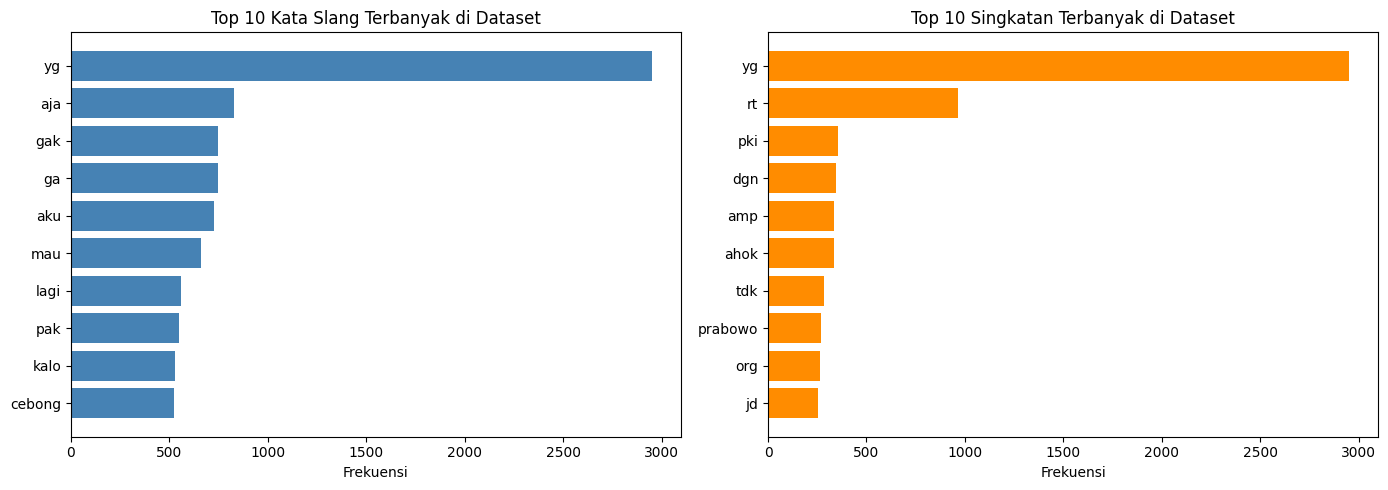

In [39]:
# Visualisasi top kata slang
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot slang
slang_words = [x[0] for x in top_slang]
slang_counts = [x[1] for x in top_slang]
axes[0].barh(slang_words[::-1], slang_counts[::-1], color='steelblue')
axes[0].set_title('Top 10 Kata Slang Terbanyak di Dataset', fontsize=12)
axes[0].set_xlabel('Frekuensi')

# Plot abbreviation
abbrev_words = [x[0] for x in top_abbrev]
abbrev_counts = [x[1] for x in top_abbrev]
axes[1].barh(abbrev_words[::-1], abbrev_counts[::-1], color='darkorange')
axes[1].set_title('Top 10 Singkatan Terbanyak di Dataset', fontsize=12)
axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.show()

# Simpan jika gambar belum ada
if not os.path.exists('images/lexical_normalization_analysis.png'):
  plt.savefig('images/lexical_normalization_analysis.png', dpi=150, bbox_inches='tight')

## 7. Text Representation: TF-IDF

Mengubah teks yang sudah dipreproses menjadi representasi numerik menggunakan TF-IDF.

In [40]:
# Hapus baris yang processed_text-nya kosong
df_clean = df[df['processed_text'].notna() & (df['processed_text'].str.strip() != '')].copy()
print(f'Jumlah data setelah membersihkan baris kosong: {len(df_clean)}')

# Fitur dan label
X = df_clean['processed_text']
y = df_clean['HS']

print(f'Distribusi label:')
print(y.value_counts())
print(f'\nProporsi Hate Speech  : {y.mean()*100:.1f}%')
print(f'Proporsi Non Hate Speech: {(1-y.mean())*100:.1f}%')

Jumlah data setelah membersihkan baris kosong: 13167
Distribusi label:
HS
0    7607
1    5560
Name: count, dtype: int64

Proporsi Hate Speech  : 42.2%
Proporsi Non Hate Speech: 57.8%


In [41]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y     
)

print(f'Data training : {len(X_train)} tweet')
print(f'Data testing  : {len(X_test)} tweet')

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,    # ambil 10000 fitur kata teratas
    ngram_range=(1, 2),   # unigram dan bigram
    min_df=2,             # abaikan kata yang hanya muncul di 1 dokumen
    sublinear_tf=True     # gunakan log normalization untuk TF
)

# Fit pada data training, transform keduanya
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nUkuran matriks TF-IDF training : {X_train_tfidf.shape}')
print(f'Ukuran matriks TF-IDF testing  : {X_test_tfidf.shape}')
print(f'\nJumlah fitur (kata) yang digunakan: {len(tfidf.get_feature_names_out())}')

Data training : 10533 tweet
Data testing  : 2634 tweet

Ukuran matriks TF-IDF training : (10533, 10000)
Ukuran matriks TF-IDF testing  : (2634, 10000)

Jumlah fitur (kata) yang digunakan: 10000


## 8. Pemodelan: Naive Bayes

Melatih model Multinomial Naive Bayes untuk mengklasifikasikan tweet sebagai Hate Speech atau Non Hate Speech.

In [42]:
# Inisialisasi dan latih model
model = MultinomialNB(alpha=0.1)   # alpha: Laplace smoothing
model.fit(X_train_tfidf, y_train)

# Prediksi pada data testing
y_pred = model.predict(X_test_tfidf)

print(f'Akurasi pada data testing: {accuracy_score(y_test, y_pred)*100:.2f}%')

Akurasi pada data testing: 81.62%


## 8b. Pemodelan Tanpa Lexical Normalization (Perbandingan)

In [43]:
# Siapkan data tanpa lexical normalization
df_clean2 = df[df['processed_text_no_lexnorm'].notna() & 
               (df['processed_text_no_lexnorm'].str.strip() != '')].copy()

X2 = df_clean2['processed_text_no_lexnorm']
y2 = df_clean2['HS']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

tfidf2 = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X2_train_tfidf = tfidf2.fit_transform(X2_train)
X2_test_tfidf  = tfidf2.transform(X2_test)

model2 = MultinomialNB(alpha=0.1)
model2.fit(X2_train_tfidf, y2_train)
y2_pred = model2.predict(X2_test_tfidf)

print(f'Akurasi Tanpa Lexical Normalization: {accuracy_score(y2_test, y2_pred)*100:.2f}%')

Akurasi Tanpa Lexical Normalization: 82.65%


## 9. Evaluasi Model

In [44]:
# Classification Report
print('Classification Report')
print(classification_report(
    y_test, y_pred,
    target_names=['Non Hate Speech (0)', 'Hate Speech (1)']
))

Classification Report
                     precision    recall  f1-score   support

Non Hate Speech (0)       0.83      0.85      0.84      1522
    Hate Speech (1)       0.79      0.77      0.78      1112

           accuracy                           0.82      2634
          macro avg       0.81      0.81      0.81      2634
       weighted avg       0.82      0.82      0.82      2634



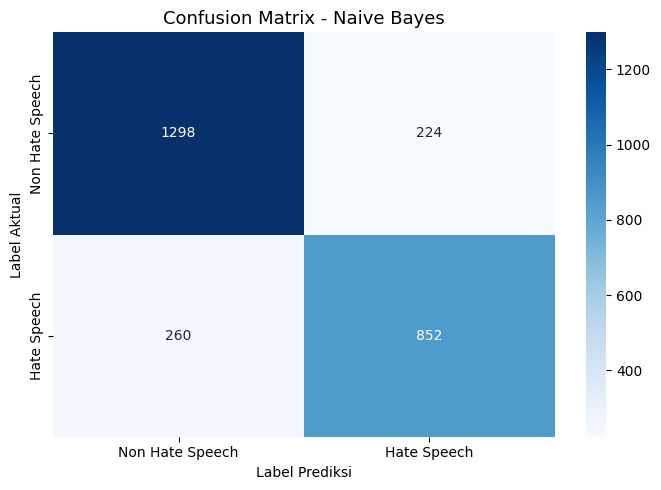

In [45]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non Hate Speech', 'Hate Speech'],
    yticklabels=['Non Hate Speech', 'Hate Speech']
)
plt.title('Confusion Matrix - Naive Bayes', fontsize=13)
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

# Simpan jika gambar belum ada
if not os.path.exists('images/confusion_matrix.png'):
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')

## 9b. Perbandingan Hasil Evaluasi

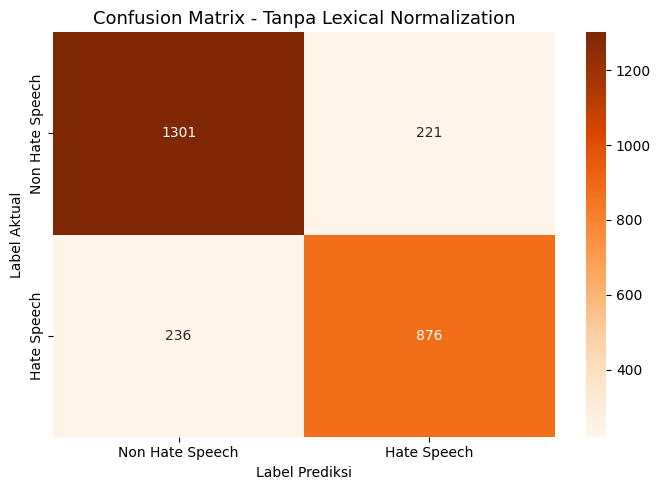

In [46]:
# Confusion Matrix model tanpa Lexical Normalization
cm2 = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Non Hate Speech', 'Hate Speech'],
    yticklabels=['Non Hate Speech', 'Hate Speech']
)
plt.title('Confusion Matrix - Tanpa Lexical Normalization', fontsize=13)
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

Perbandingan Performa Model:


,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
Model,,,,
Dengan Lexical Normalization,81.62,79.18,76.62,77.88
Tanpa Lexical Normalization,82.65,79.85,78.78,79.31


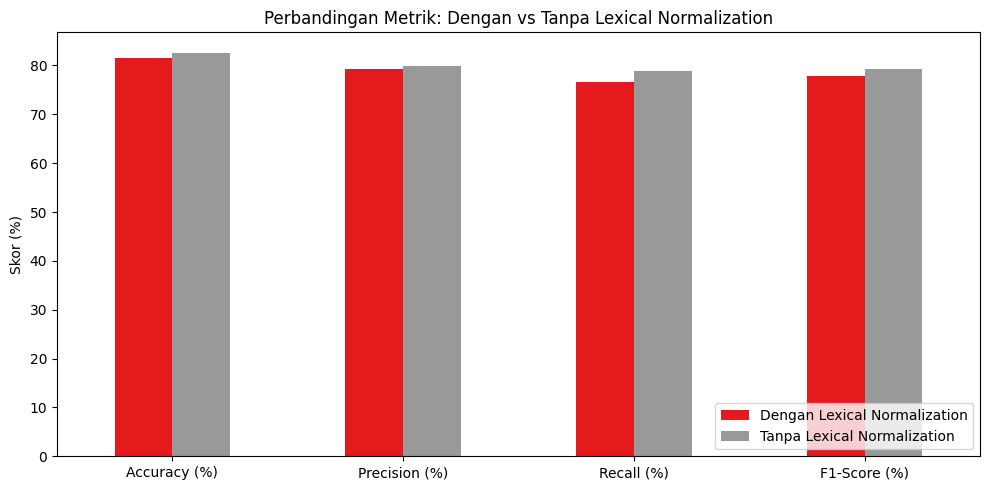

In [47]:
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'Model': ['Dengan Lexical Normalization', 'Tanpa Lexical Normalization'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, y_pred)*100, 2),
        round(accuracy_score(y2_test, y2_pred)*100, 2)
    ],
    'Precision (%)': [
        round(precision_score(y_test, y_pred)*100, 2),
        round(precision_score(y2_test, y2_pred)*100, 2)
    ],
    'Recall (%)': [
        round(recall_score(y_test, y_pred)*100, 2),
        round(recall_score(y2_test, y2_pred)*100, 2)
    ],
    'F1-Score (%)': [
        round(f1_score(y_test, y_pred)*100, 2),
        round(f1_score(y2_test, y2_pred)*100, 2)
    ],
}

df_comparison = pd.DataFrame(metrics).set_index('Model')
print("Perbandingan Performa Model:")
display(df_comparison)

# Visualisasi
df_comparison.T.plot(kind='bar', figsize=(10, 5), colormap='Set1')
plt.title('Perbandingan Metrik: Dengan vs Tanpa Lexical Normalization')
plt.ylabel('Skor (%)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Uji Coba Prediksi Tweet Baru

In [48]:
def predict_tweet(tweet, preprocessor, tfidf_vectorizer, model):
    # Preproses tweet
    processed = preprocessor.preprocess(tweet)
    # Vectorize
    vec = tfidf_vectorizer.transform([processed])
    # Prediksi
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]

    label = 'Hate Speech' if pred == 1 else 'Non Hate Speech'
    print(f'Tweet      : {tweet}')
    print(f'Setelah preprocessing: {processed}')
    print(f'Prediksi   : {label}')
    print(f'Probabilitas Non Hate Speech : {prob[0]*100:.1f}%  |  Hate Speech: {prob[1]*100:.1f}%\n')


# Coba prediksi beberapa tweet
tweet_baru = [
    # Non Hate Speech
    "Selamat pagi semua, semoga harimu menyenangkan!",
    "Makasih banyak udah bantu gue kemarin, baik banget!",

    # Hate Speech
    "Dasar goblok lo, emang dari sananya bodoh!",
    "Gue benci banget sama orang-orang kaya gitu, bangsat semua!",
    "Orang-orang dari suku itu emang dasarnya ga bisa dipercaya",
    "Kafir semua harus diusir dari negeri ini",

    # Netral/berita
    "Hari ini Jakarta hujan deras sejak pagi",
    "Tim nasional Indonesia menang 2-1 tadi malam",

    # Kasus Tricky
    "Gue ga benci dia, gue cuma kecewa sama sikapnya",
    "Gua paling benci ama yang kayak gini!",
    "Anjir lo gila, lucu banget sumpah wkwk",
    "Wajar aja mereka miskin, dari sono emang pemalas",
    "Orang macam itu memang tidak ada gunanya hidup di sini",
]

print('Hasil Prediksi Tweet Baru')
for tweet in tweet_baru:
    predict_tweet(tweet, preprocessor, tfidf, model)

Hasil Prediksi Tweet Baru
Tweet      : Selamat pagi semua, semoga harimu menyenangkan!
Setelah preprocessing: selamat pagi semua moga hari senang
Prediksi   : Non Hate Speech
Probabilitas Non Hate Speech : 90.3%  |  Hate Speech: 9.7%

Tweet      : Makasih banyak udah bantu gue kemarin, baik banget!
Setelah preprocessing: terima kasih banyak bantu kemarin baik sangat
Prediksi   : Non Hate Speech
Probabilitas Non Hate Speech : 91.6%  |  Hate Speech: 8.4%

Tweet      : Dasar goblok lo, emang dari sananya bodoh!
Setelah preprocessing: dasar bodoh kamu memang sana bodoh
Prediksi   : Hate Speech
Probabilitas Non Hate Speech : 0.6%  |  Hate Speech: 99.4%

Tweet      : Gue benci banget sama orang-orang kaya gitu, bangsat semua!
Setelah preprocessing: benci sangat sama orang orang kaya buruk semua
Prediksi   : Hate Speech
Probabilitas Non Hate Speech : 46.6%  |  Hate Speech: 53.4%

Tweet      : Orang-orang dari suku itu emang dasarnya ga bisa dipercaya
Setelah preprocessing: orang orang suku me

## 11. Simpan Data

In [49]:
# Simpan dataset yang sudah dipreproses jika belum ada
if not os.path.exists('data/preprocessed_data_final.csv'):
  df_clean.to_csv('preprocessed_data_final.csv', index=False)
  print('Dataset tersimpan: preprocessed_data_final.csv')

## 12. Ekspor Model

In [50]:
# Simpan model jika belum ada
if not os.path.exists('model/'):
    # Simpan model Naive Bayes
    with open('model_naive_bayes.pkl', 'wb') as f:
        pickle.dump(model, f)

    # Simpan TF-IDF vectorizer
    with open('tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump(tfidf, f)

    # Simpan preprocessor 
    with open('preprocessor.pkl', 'wb') as f:
        pickle.dump(preprocessor, f)